Fecha de referencia: 2011-12-10
Filas eliminadas: 562


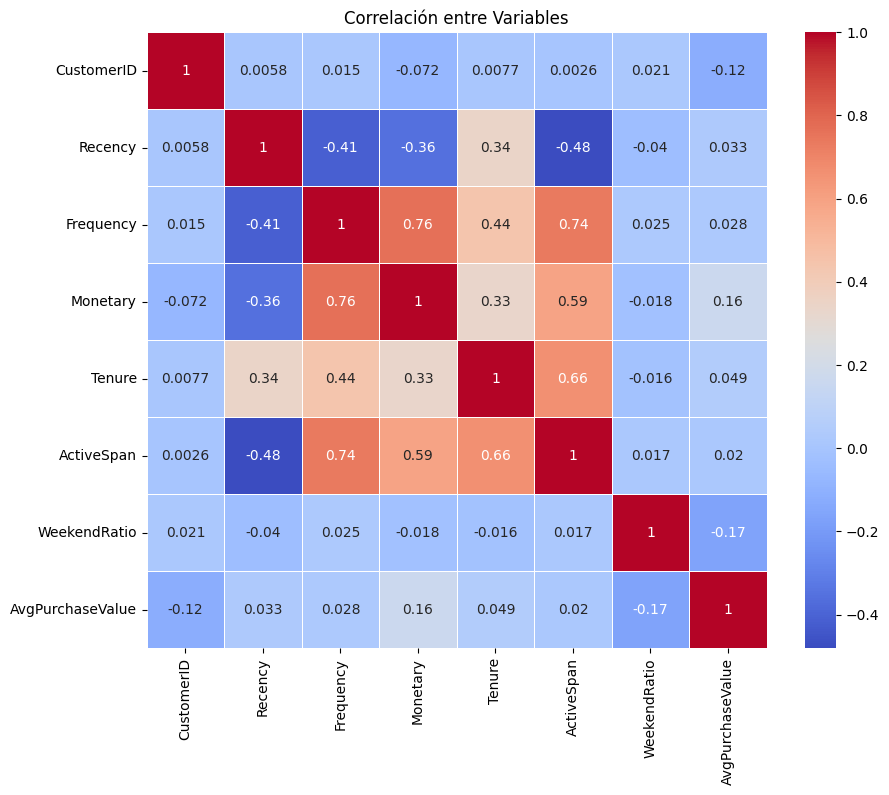

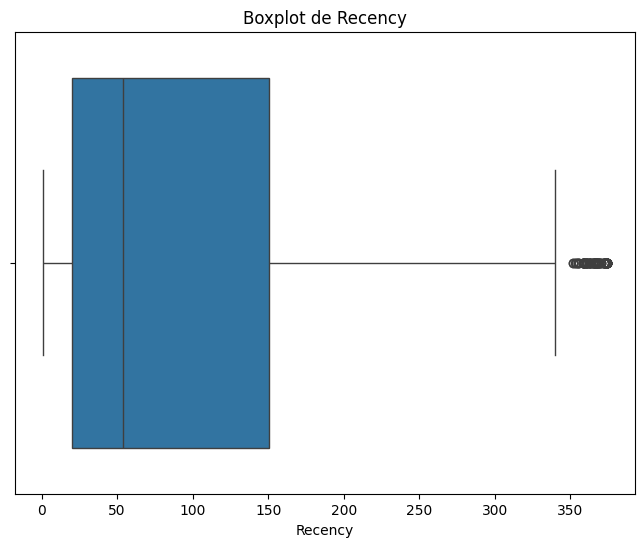

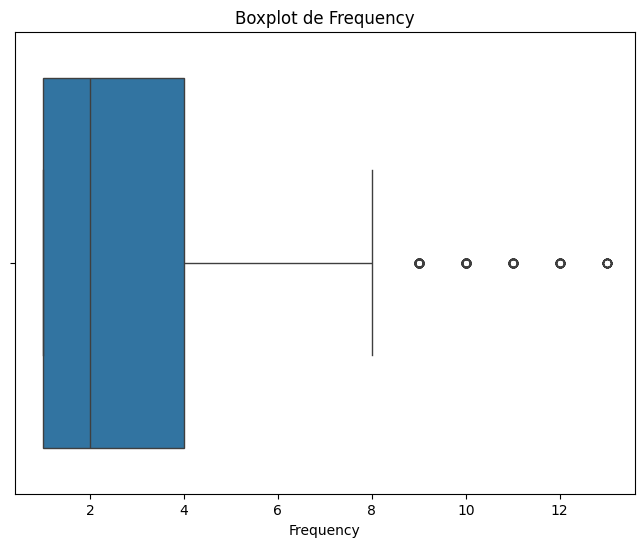

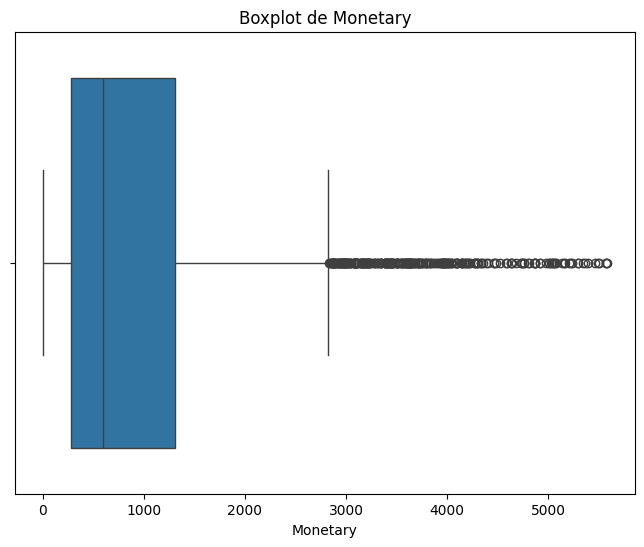

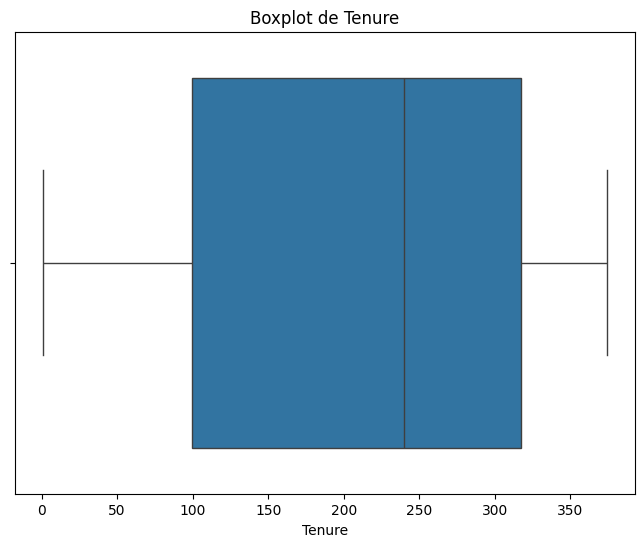

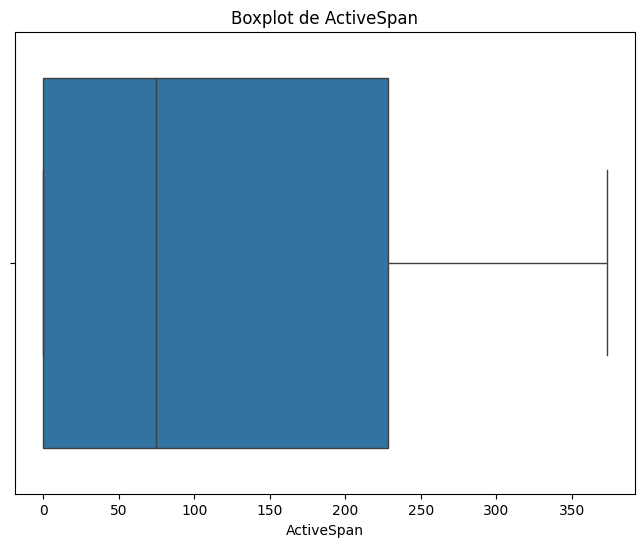

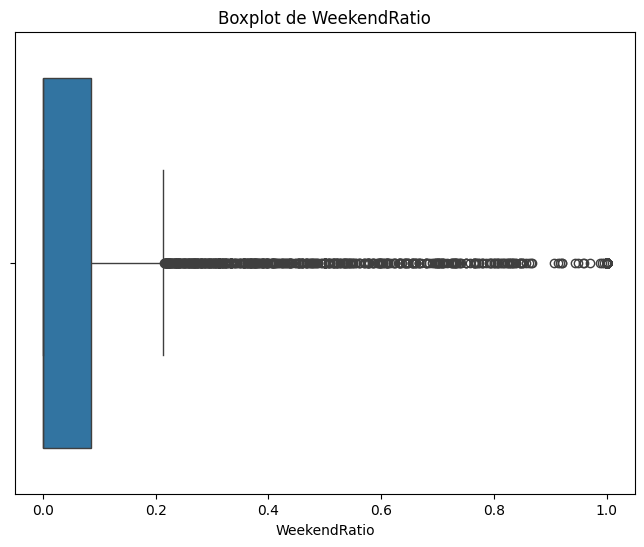

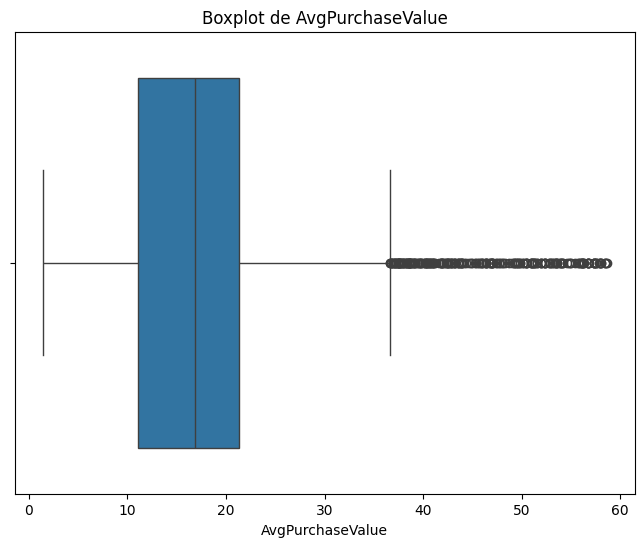

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import MinMaxScaler

#Cargamos los datasets tanto de ventas como de devoluciones

df_ventas = pd.read_csv('/content/data_v01_clustering_ventas.csv')
df_devoluciones = pd.read_csv('/content/data_v01_clustering_devoluciones.csv')

df_ventas['InvoiceDate'] = pd.to_datetime(df_ventas['InvoiceDate'])
fecha_ref = df_ventas['InvoiceDate'].max() + pd.Timedelta(days=1)


print(f"Fecha de referencia: {fecha_ref.date()}")

rfm = df_ventas.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (fecha_ref - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum'),
    Tenure    = ('InvoiceDate', lambda x: (fecha_ref - x.min()).days)
).reset_index()


rfm['ActiveSpan'] = rfm['Tenure'] - rfm['Recency']



# Calculamos compras en fin de semana por cliente
weekend_stats = df_ventas.groupby('CustomerID').agg(
    total_compras    = ('InvoiceNo', 'count'),
    compras_finde    = ('IsWeekend', 'sum')
).reset_index()

# Opción  ratio: % de compras en fin de semana
weekend_stats['WeekendRatio'] = (weekend_stats['compras_finde'] / weekend_stats['total_compras']).round(3)

# Añadimos al rfm
rfm = rfm.merge(weekend_stats[['CustomerID','WeekendRatio']], on='CustomerID', how='left')

#Añadimos media de compras por clientes
mean_purchases = df_ventas.groupby('CustomerID').agg(
    AvgPurchaseValue = ('TotalPrice', 'mean')
).round(3).reset_index()

rfm = rfm.merge(mean_purchases, on='CustomerID', how='left')



def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[column] >= Q1 - 3 * IQR) &
              (df[column] <= Q3 + 3 * IQR)]

rfm_clean = rfm.copy()
rfm_clean = remove_outliers_iqr(rfm_clean, 'Monetary')
rfm_clean = remove_outliers_iqr(rfm_clean, 'AvgPurchaseValue')
rfm_clean = remove_outliers_iqr(rfm_clean, 'Frequency')
#Mostramos el numero de filas eliminadas
print(f"Filas eliminadas: {rfm.shape[0] - rfm_clean.shape[0]}")


#Grafico de heatmap entre variables
plt.figure(figsize=(10, 8))
sns.heatmap(rfm_clean.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlación entre Variables')
plt.show()


#Mostramos un boxplot de cada una de nuestras variables
for col in rfm_clean.columns[1:]:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=rfm_clean[col])
    plt.title(f'Boxplot de {col}')
    plt.show()





# K-MEANS
Es un algortitmo de segmentacion no supervisado.
Funcionamiento del algoritmo:
Se pintan diferentes puntos aleatorios en el plano , se claculan las distancias de los puntos a los centroides pintados , los centroides se puede pintar de manera aleatoria , el numero de centroides es la K , es decir si tenemos k= 3 , queremos que nuestro modelo haga una segmentacion en tres grupos.

Una vez esten calculadas las distancias de los puntos con los centroides , estos se recalculan (se hace la media las distancias de los puntos al centroide mas cercano) el centoride se va moviendo en cada iteraccion hasta que se queda totalmente quieto.

# Métricas
Parta medir el funcionamiento y resultado de nuestro modelo tenemos las siguientes metricas:

Silhouet -> Mide como de separados estan los clusteres , un resultado cercano a 0 indica mala separacion de nuestros clusters y uno cercano a 1 , los clusters se separan bien.

Las inercias-> Las inercias indican como de separados estan nuestros puntos dentro del cluster


*  Inercia alta → clusters mal formados, puntos dispersos
*  Inercia baja → clusters compactos, puntos cerca de su centroide




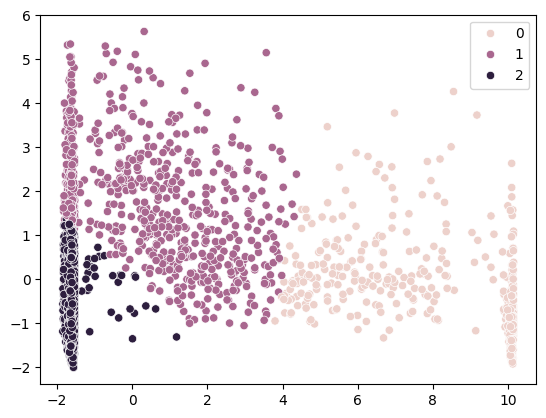

Clusters: 3, Silhouette Score: 0.43634662114118666


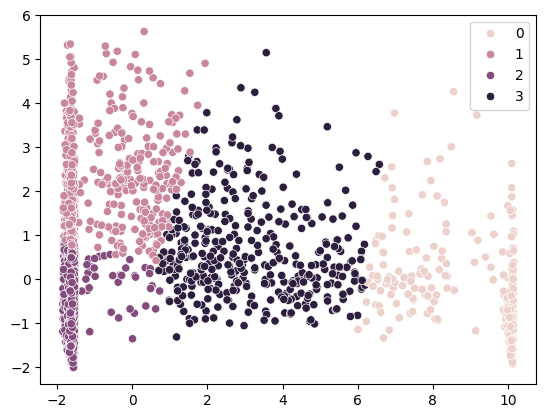

Clusters: 4, Silhouette Score: 0.41279648262801405


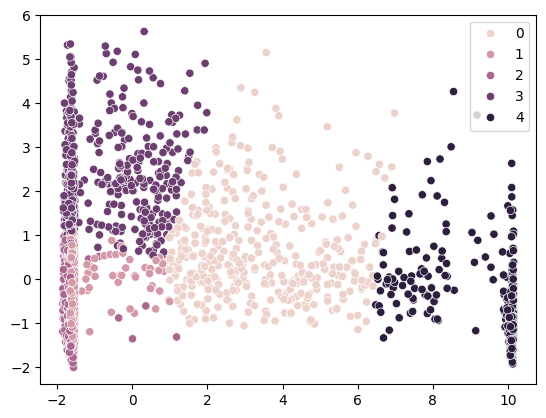

Clusters: 5, Silhouette Score: 0.30855856533693593


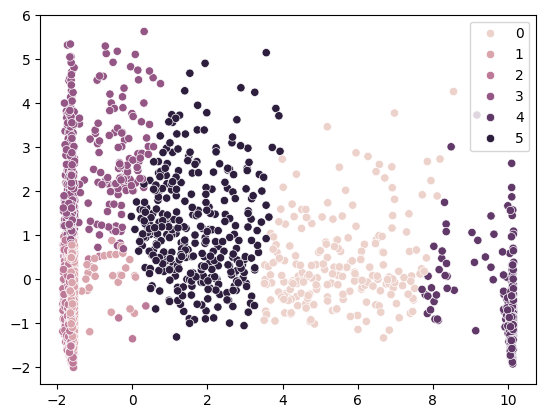

Clusters: 6, Silhouette Score: 0.3058044915714331


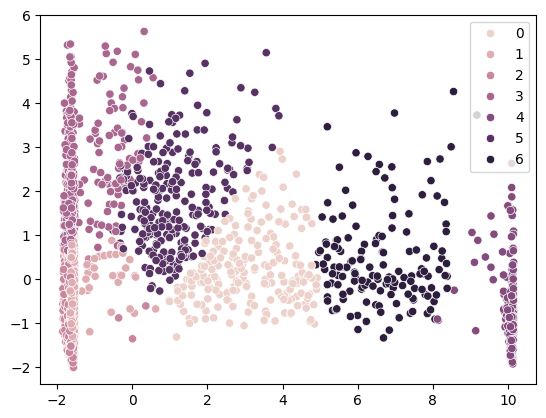

Clusters: 7, Silhouette Score: 0.2928357998385803


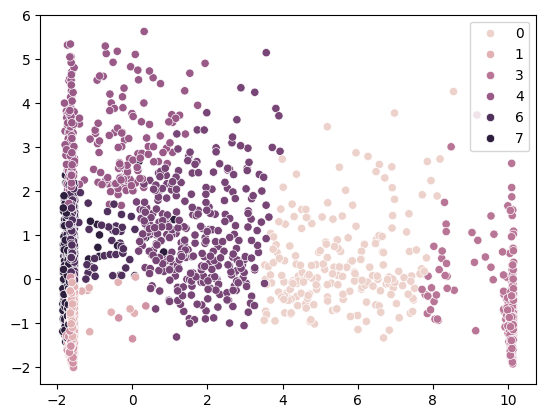

Clusters: 8, Silhouette Score: 0.3156907816144833


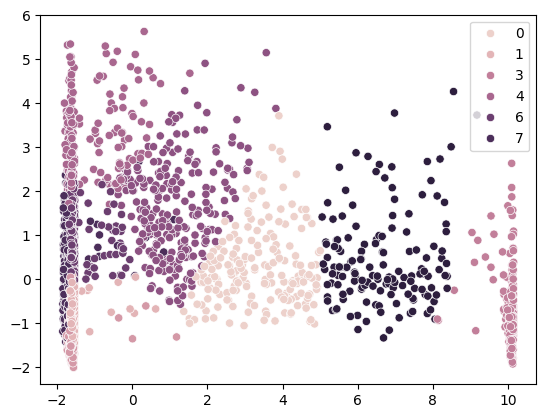

Clusters: 9, Silhouette Score: 0.30532139327121255


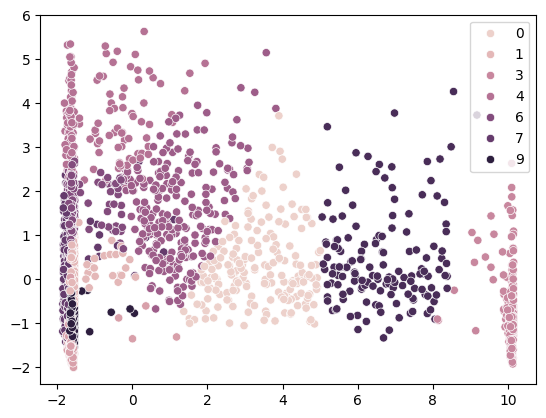

Clusters: 10, Silhouette Score: 0.2780597403577943


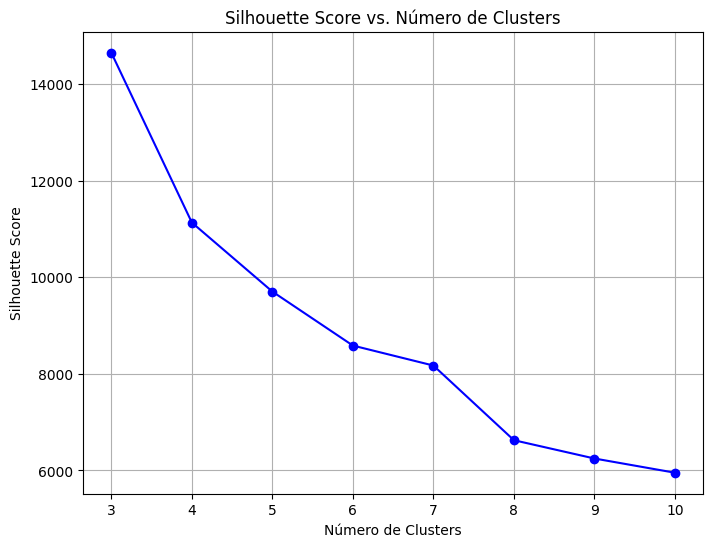

In [38]:
from sklearn.decomposition import PCA

X = rfm_clean[['Recency', 'Frequency', 'Monetary', 'ActiveSpan', 'WeekendRatio', 'AvgPurchaseValue']]

k_list = [3,4,5,6,7,8,9,10]
silhouette_scores = []
inertias = []


#Escalamos los datos
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

#Hacemos reduccion de dimensionalidad con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


for k in k_list:
  kmeans = KMeans(init = "k-means++",n_clusters= k,random_state=42)
  kmeans.fit(X_scaled)

  inertias.append(kmeans.inertia_)

  labels = kmeans.labels_
  silhouette_avg = silhouette_score(X_scaled, labels)
  silhouette_scores.append(silhouette_avg)

  sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels)
  plt.show()


  print(f"Clusters: {k}, Silhouette Score: {silhouette_avg}")


plt.figure(figsize=(8, 6))
plt.plot(k_list,inertias, 'bo-')
plt.xlabel('Número de Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Número de Clusters')
plt.grid(True)
plt.show()

# Algoritmo DBSCAN
Es aun algortimo de Machine Learning de agrupamiento espacial , no supervisado ,basado en la densidad que crea los clusters con valor de densidad proporcionado por el usuario.
Este valor de densidad se coloca al rededor de un centroide , el area de alrededor del centroide se llama vecindad , y dbscan intenta definir el numero de vecindadiors de los clusters de una determinada densidad especifica.

DBSCAN puede decubir clusters de culaquier forma , densidad o tamaño en los datos, ideal para dataset ruidosos o con valores atipicos, tambien cuando el numero de clusters no se sabe.

Tambien distinggue entre los puntos que pertenecen a un cluster y los que son ruido.

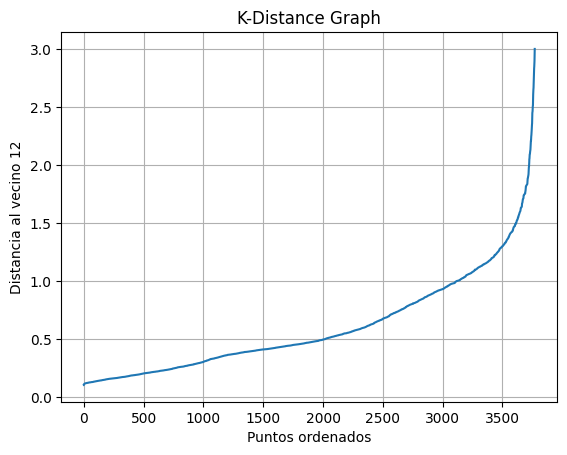

(3771, 6)
Min Samples: 13, Silhouette Score: 0.4007655885193543


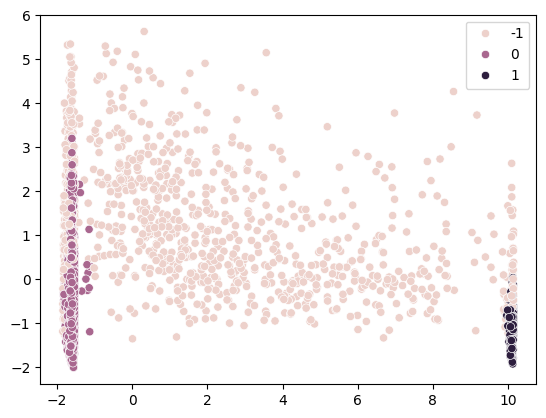

In [39]:
from sklearn import neighbors
#Importamos la libreria de DBSCAN
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors


neighbors = NearestNeighbors(n_neighbors=13)
neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

distances = np.sort(distances[:, -1])

plt.plot(distances)
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia al vecino 12')
plt.title('K-Distance Graph')
plt.grid(True)
plt.show()

silhouette_scores_dbscan = []
minsaples = 13

print(X_scaled.shape)


#Definimos el modelo
dbscan_model = DBSCAN(eps=0.6, min_samples=minsaples)

#Entrenamos el modelo
dbscan_model.fit(X_scaled)

labels = dbscan_model.labels_

#Calculamos el silhouette score
silhouette_avg_dbs = silhouette_score(X_scaled, labels)
silhouette_scores_dbscan.append(silhouette_avg_dbs)


print(f"Min Samples: {minsaples}, Silhouette Score: {silhouette_avg_dbs}")
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels)
plt.show()





